In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import seaborn as sns

df = pd.read_csv('C:\internship\major\seasonal_agriculture_performance_dataset (3).csv')

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
C:\Users\PRATIK\AppData\Local\Temp\ipykernel_37788\1562573353.py:6: SyntaxWarning: invalid escape sequence '\i'
  df = pd.read_csv('C:\internship\major\seasonal_agriculture_performance_dataset (3).csv')


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [10]:
print("Seasons:")
print(df["Season"].unique())

print("\nCrops:")
print(df["Crop"].unique())

print("\nNumber of States:")
print(df["State"].nunique())

Seasons:
['Kharif' 'Rabi' 'Zaid']

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Number of States:
8


In [11]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [12]:
df.isnull().sum()


Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [13]:
df.isnull().sum()[df.isnull().sum() > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [14]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

In [15]:
df.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

In [16]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [17]:
df[["Rainfall_mm", "Yield_Tonnes_Ha", "Profit_INR"]].describe()


,Rainfall_mm,Yield_Tonnes_Ha,Profit_INR
count,4000.000000,4000.000000,4.000000e+03
mean,600.922825,5.242350,1.115565e+05
std,287.193381,13.311549,5.450819e+05
min,80.000000,0.300000,-1.019223e+06
25%,371.575000,1.050000,-1.487318e+05
50%,582.000000,1.740000,3.673000e+03
75%,831.975000,2.830000,2.161878e+05
max,1395.200000,101.440000,4.345421e+06


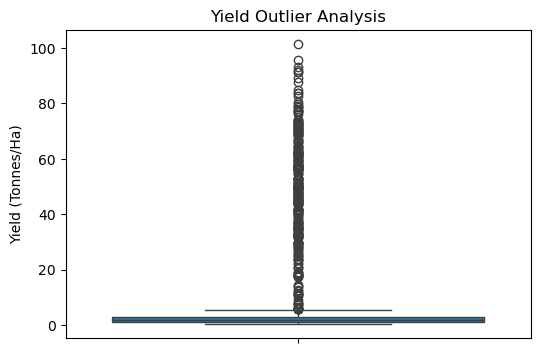

In [18]:
#Yeild Outlier Check
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Yield_Tonnes_Ha"])
plt.title("Yield Outlier Analysis")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

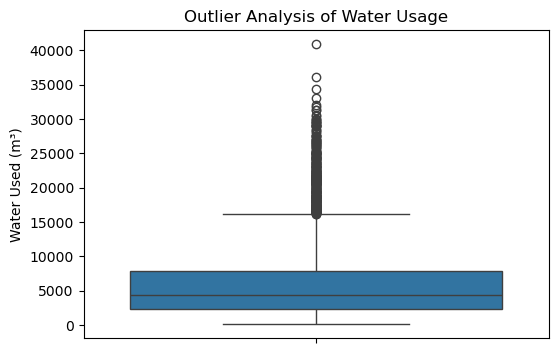

In [19]:
#Waterusage Outlier Check
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Water_Used_m3"])
plt.title("Outlier Analysis of Water Usage")
plt.ylabel("Water Used (m³)")
plt.show()

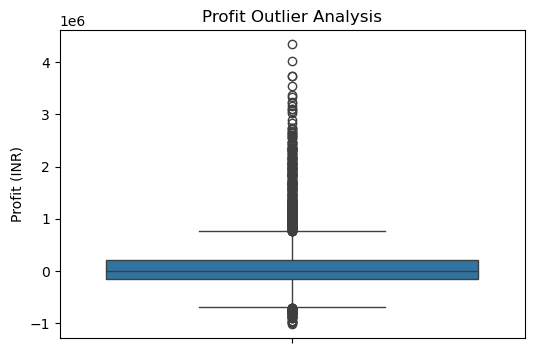

In [20]:
#Profit Outlier Check
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Profit_INR"])
plt.title("Profit Outlier Analysis")
plt.ylabel("Profit (INR)")
plt.show()

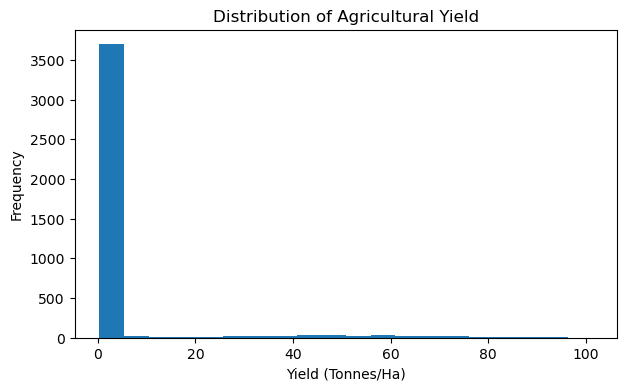

In [21]:
#Univariate Analysis 
plt.figure(figsize=(7, 4))
plt.hist(df["Yield_Tonnes_Ha"], bins=20)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.show()

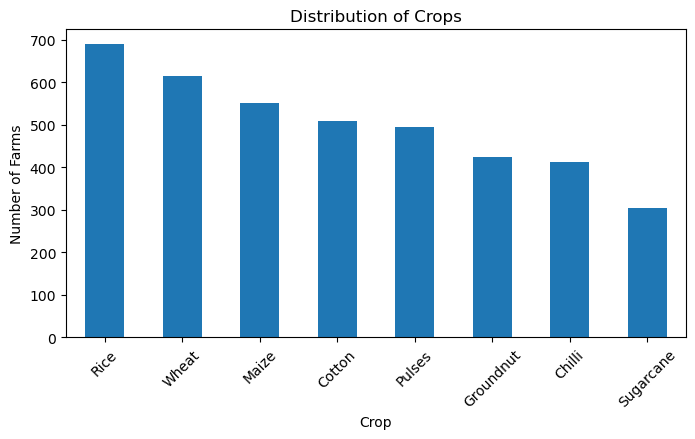

In [22]:
plt.figure(figsize=(8, 4))
df["Crop"].value_counts().plot(kind="bar")

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

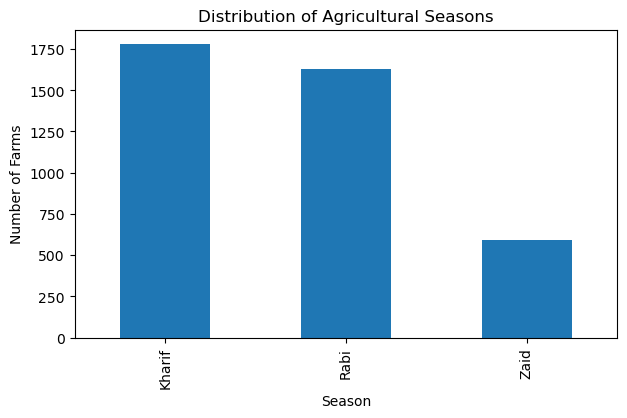

In [23]:
plt.figure(figsize=(7, 4))
df["Season"].value_counts().plot(kind="bar")

plt.title("Distribution of Agricultural Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()

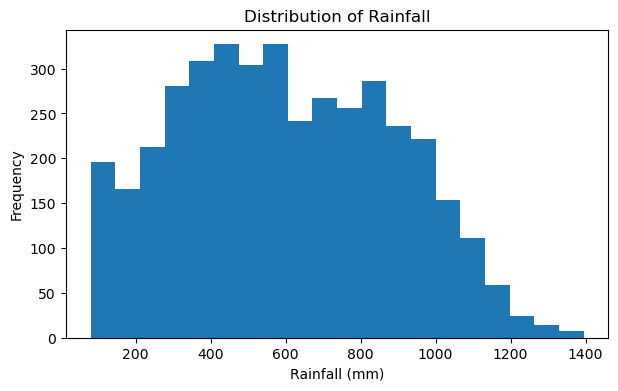

In [24]:
plt.figure(figsize=(7, 4))
plt.hist(df["Rainfall_mm"], bins=20)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

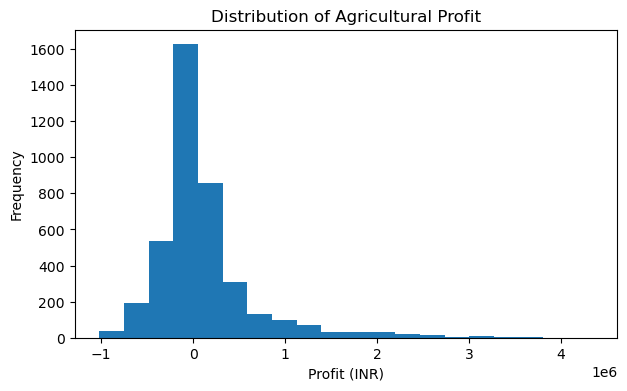

In [25]:
plt.figure(figsize=(7, 4))
plt.hist(df["Profit_INR"], bins=20)

plt.title("Distribution of Agricultural Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.show()

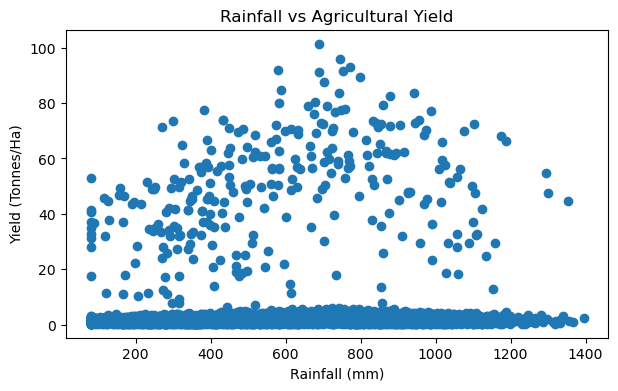

In [26]:
#Bivariate Analysis: Rainfall vs Yield
plt.figure(figsize=(7, 4))

plt.scatter(df["Rainfall_mm"], df["Yield_Tonnes_Ha"])

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

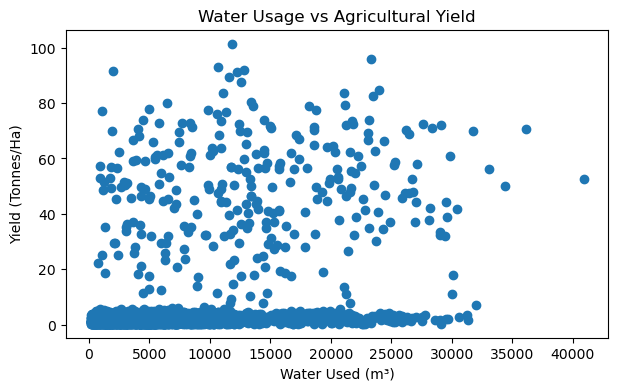

In [27]:
#Bivariate Analysis: Water Usage vs Yield
plt.figure(figsize=(7, 4))

plt.scatter(df["Water_Used_m3"], df["Yield_Tonnes_Ha"])

plt.title("Water Usage vs Agricultural Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

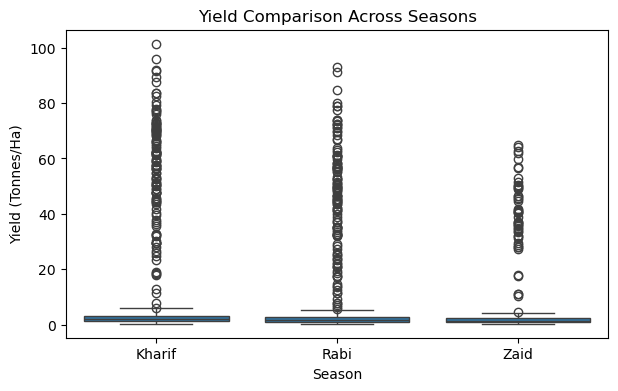

In [28]:
#Bivariate Analysis: Season vs Yield
plt.figure(figsize=(7, 4))

sns.boxplot(x="Season", y="Yield_Tonnes_Ha", data=df)

plt.title("Yield Comparison Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

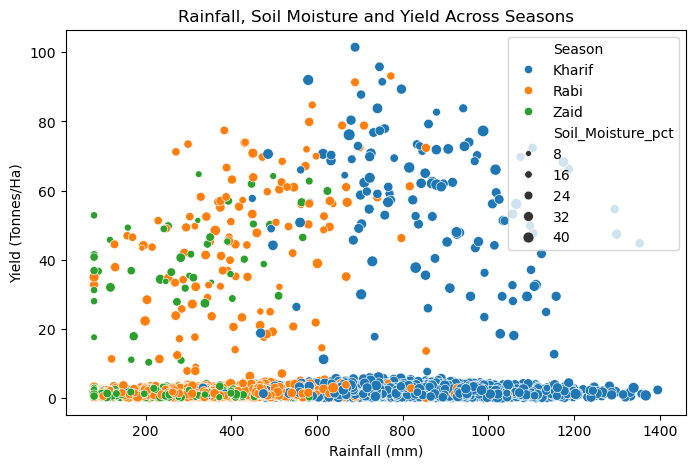

In [29]:
#Multivariate Analysis
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Soil_Moisture_pct"
)

plt.title("Rainfall, Soil Moisture and Yield Across Seasons")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [30]:
#Correlation Analysis
correlation_data = df[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Soil_Moisture_pct",
        "Yield_Tonnes_Ha"
    ]
]

correlation_data.corr()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.198492,0.521069,0.508941,0.030951
Avg_Temperature_C,0.198492,1.000000,0.138136,0.084001,0.009996
Humidity_pct,0.521069,0.138136,1.000000,0.446470,0.012297
Soil_Moisture_pct,0.508941,0.084001,0.446470,1.000000,0.010999
Yield_Tonnes_Ha,0.030951,0.009996,0.012297,0.010999,1.000000


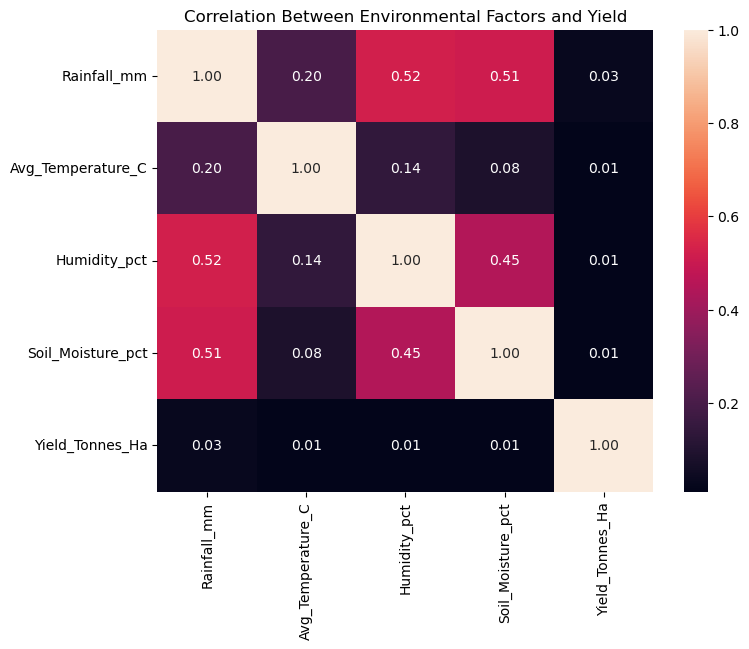

In [31]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Environmental Factors and Yield")
plt.show()

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


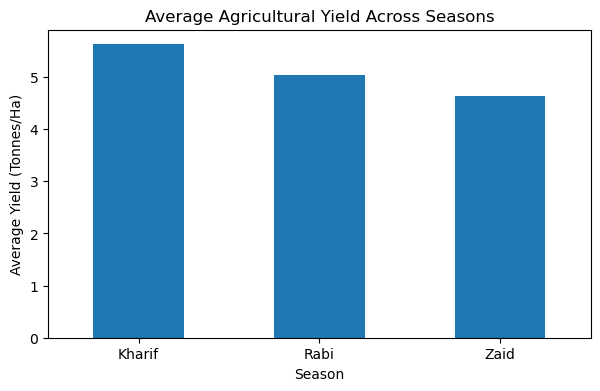

In [32]:
#Seasonal Comparison: Average Yield
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print(season_yield)
plt.figure(figsize=(7, 4))

season_yield.plot(kind="bar")

plt.title("Average Agricultural Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=0)
plt.show()

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


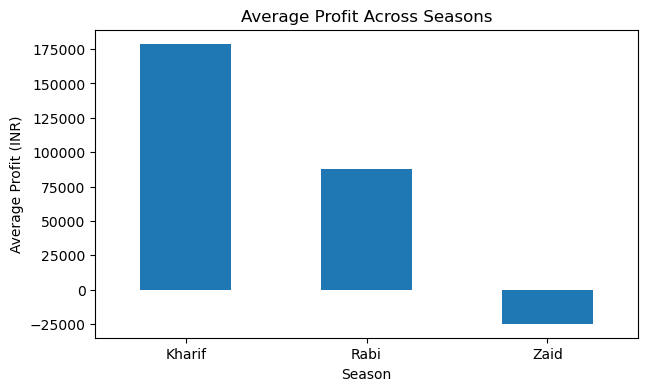

In [33]:
#Seasonal Comparison: Average Profit
season_profit = df.groupby("Season")["Profit_INR"].mean()

print(season_profit)
plt.figure(figsize=(7, 4))

season_profit.plot(kind="bar")

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=0)
plt.show()

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


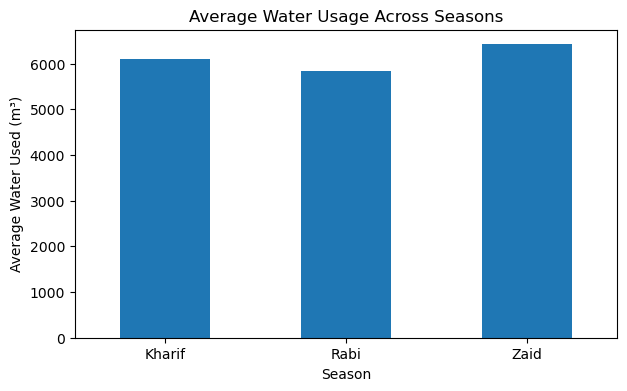

In [34]:
#Seasonal Comparison: Water Usage
season_water = df.groupby("Season")["Water_Used_m3"].mean()

print(season_water)
plt.figure(figsize=(7, 4))

season_water.plot(kind="bar")

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")

plt.xticks(rotation=0)
plt.show()


## Which season shows better agricultural performance in terms of yield and profit?

,Crop,Average_Yield,Average_Profit
6,Sugarcane,46.64,817187.99
3,Maize,2.71,-83978.33
5,Rice,2.43,-102213.50
7,Wheat,2.11,-123398.34
0,Chilli,1.54,750878.34
2,Groundnut,1.32,44858.12
1,Cotton,1.23,124546.92
4,Pulses,0.92,-4238.05


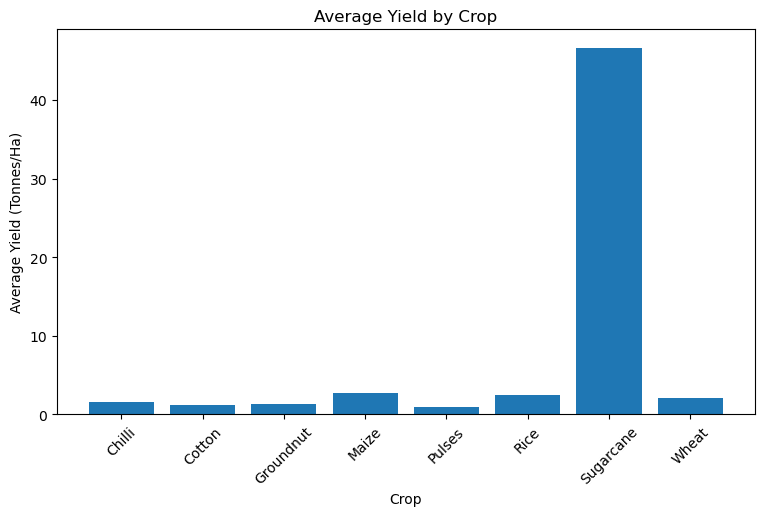

In [35]:
crop_performance = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

display(
    crop_performance
    .sort_values("Average_Yield", ascending=False)
    .round(2)
)
plt.figure(figsize=(9, 5))

plt.bar(
    crop_performance["Crop"],
    crop_performance["Average_Yield"]
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()


## Which crops perform better based on average yield and profit?

,Season,Average_Yield,Average_Profit
0,Kharif,5.63,178914.65
1,Rabi,5.04,87689.47
2,Zaid,4.64,-24804.82


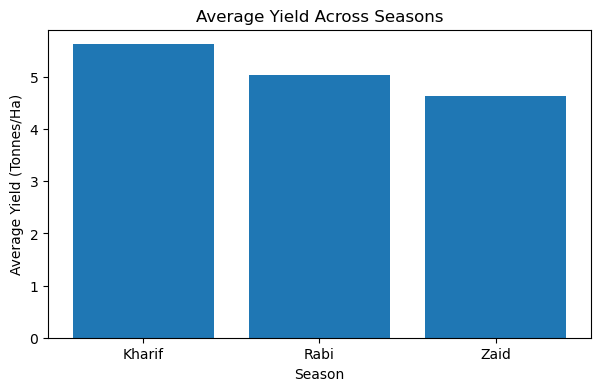

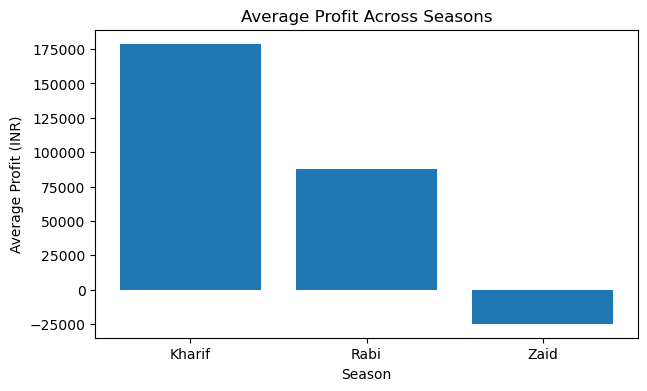

In [36]:
season_performance = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

display(
    season_performance
    .sort_values("Average_Yield", ascending=False)
    .round(2)
)
plt.figure(figsize=(7, 4))

plt.bar(
    season_performance["Season"],
    season_performance["Average_Yield"]
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()
plt.figure(figsize=(7, 4))

plt.bar(
    season_performance["Season"],
    season_performance["Average_Profit"]
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()


##  How does rainfall and water usage vary across different seasons?

,Season,Average_Rainfall
0,Kharif,849.20
1,Rabi,437.62
2,Zaid,304.65


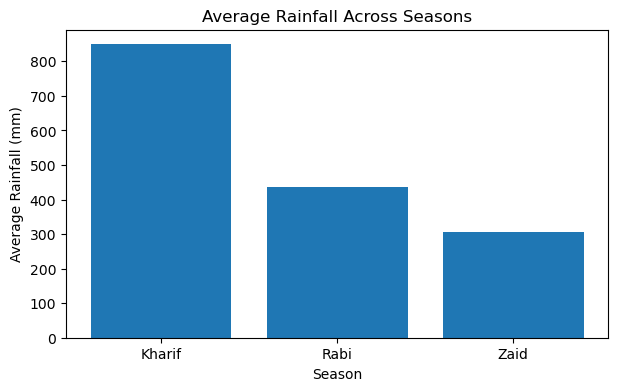

In [37]:
season_resources = df.groupby("Season").agg(
    Average_Rainfall=("Rainfall_mm", "mean"),
   
).reset_index()

display(
    season_resources
    .sort_values("Average_Rainfall", ascending=False)
    .round(2)
)
plt.figure(figsize=(7, 4))

plt.bar(
    season_resources["Season"],
    season_resources["Average_Rainfall"]
)

plt.title("Average Rainfall Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.show()



## Which states show better agricultural performance based on average yield?

,State,Average_Yield,Average_Profit
5,Punjab,6.12,136025.64
2,Karnataka,5.69,119422.34
1,Gujarat,5.66,117568.24
7,Telangana,5.04,108829.62
4,Maharashtra,5.02,135428.86
3,Madhya Pradesh,4.99,86840.76
6,Tamil Nadu,4.88,117744.75
0,Andhra Pradesh,4.63,73453.53


<Figure size 1000x500 with 0 Axes>

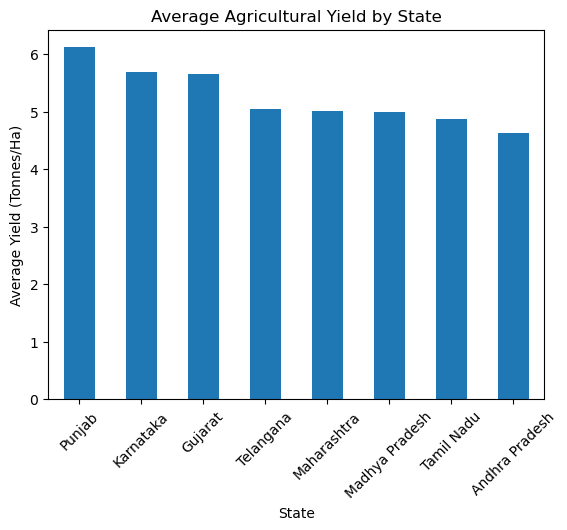

In [38]:

state_performance = df.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

display(
    state_performance
    .sort_values("Average_Yield", ascending=False)
    .round(2)
)
plt.figure(figsize=(10, 5))

state_performance.sort_values(
    "Average_Yield",
    ascending=False
).plot(
    x="State",
    y="Average_Yield",
    kind="bar",
    legend=False
)

plt.title("Average Agricultural Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [39]:


print("========== KEY FINDINGS ==========\n")

# 1. Crop distribution
most_common_crop = df["Crop"].value_counts().idxmax()
most_common_crop_count = df["Crop"].value_counts().max()

print(f"1. {most_common_crop} is the most frequently recorded crop "
      f"with {most_common_crop_count} records.")


# 2. Season distribution
most_common_season = df["Season"].value_counts().idxmax()
season_count = df["Season"].value_counts().max()

print(f"2. {most_common_season} has the highest number of farm records "
      f"with {season_count} records.")


# 3. Average yield variation
highest_yield = season_yield.max()
lowest_yield = season_yield.min()
yield_difference = highest_yield - lowest_yield

print(f"3. The difference between the highest and lowest seasonal "
      f"average yield is {yield_difference:.2f} tonnes/ha.")


# 4. Average profit variation
highest_profit = season_profit.max()
lowest_profit = season_profit.min()
profit_difference = highest_profit - lowest_profit

print(f"4. The difference between the highest and lowest seasonal "
      f"average profit is INR {profit_difference:,.2f}.")


# 5. Rainfall and yield comparison
rainfall_yield_corr = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])

print(f"5. Rainfall and yield have a correlation of "
      f"{rainfall_yield_corr:.2f}.")


# 6. Water usage and yield relationship
water_yield_corr = df["Water_Used_m3"].corr(df["Yield_Tonnes_Ha"])

print(f"6. Water usage and yield have a correlation of "
      f"{water_yield_corr:.2f}.")


# 7. Highest-profit crop
crop_profit = df.groupby("Crop")["Profit_INR"].mean()

highest_profit_crop = crop_profit.idxmax()
highest_profit_crop_value = crop_profit.max()

print(f"7. {highest_profit_crop} has the highest average profit "
      f"among the crops at INR {highest_profit_crop_value:,.2f}.")


# 8. Highest water-consuming crop
crop_water = df.groupby("Crop")["Water_Used_m3"].mean()

highest_water_crop = crop_water.idxmax()
highest_water_value = crop_water.max()

print(f"8. {highest_water_crop} has the highest average water usage "
      f"of {highest_water_value:,.2f} m³ among the crops.")

========== KEY FINDINGS ==========

1. Rice is the most frequently recorded crop with 690 records.
2. Kharif has the highest number of farm records with 1779 records.
3. The difference between the highest and lowest seasonal average yield is 0.99 tonnes/ha.
4. The difference between the highest and lowest seasonal average profit is INR 203,719.47.
5. Rainfall and yield have a correlation of 0.03.
6. Water usage and yield have a correlation of 0.39.
7. Sugarcane has the highest average profit among the crops at INR 817,187.99.
8. Sugarcane has the highest average water usage of 13,897.70 m³ among the crops.


## Evidence-Based Recommendations

1. Kharif season should be given greater attention during agricultural planning because it shows better average yield and profit compared with the other seasons.

2. Water resources should be planned carefully across seasons because water usage varies between Kharif, Rabi and Zaid. Efficient irrigation can help in reducing unnecessary water consumption.

3. Crop selection should consider both yield and profit instead of focusing only on production. A crop with high yield may not always provide the highest economic return.

4. Sugarcane should be evaluated carefully for cultivation because it shows strong performance in terms of yield and profit, but its higher water requirement should also be considered.

5. Rainfall should be considered along with other environmental factors while planning agricultural activities, rather than using rainfall alone to estimate crop yield.

6. Farmers should monitor water efficiency along with total water usage so that higher production can be achieved without excessive use of water resources.

7. Seasonal and crop-wise performance should be regularly compared to identify suitable crops and improve resource allocation for different seasons.

8. Agricultural decisions should consider economic factors such as production cost, revenue and profit along with yield to support better financial planning.

## Limitations

1. The analysis is based on the available dataset of agricultural activities and may not represent the complete agricultural conditions of all regions.

2. The dataset covers only three seasons: Kharif, Rabi and Zaid. Therefore, the results are limited to these seasonal categories.

3. The analysis identifies relationships and patterns between variables, but correlation does not prove that one variable directly causes changes in another.

4. Some real-world factors such as government policies, farmer experience, market demand, weather changes and farming decisions are not included in the analysis.

5. The dataset contains some missing values which were handled using median values. This may slightly affect the results of certain analyses.

6. Outliers were observed in variables such as yield, profit and water usage. These values may represent unusual farming conditions and can influence averages and statistical results.

7. The analysis mainly focuses on descriptive statistics, visualizations, comparisons and correlations. It does not provide future prediction using machine learning models.

8. The findings are based on the given dataset and may change if a different dataset, time period or larger sample of agricultural records is used.

## Final Conclusion

The Seasonal Agriculture Performance Analysis provides a clear understanding of agricultural performance across different seasons and crops. The analysis shows differences in yield, profit, water usage and other agricultural factors across Kharif, Rabi and Zaid seasons. Crop-wise and seasonal comparisons helped identify important patterns and variations in agricultural performance. The correlation analysis also helped understand the relationships between environmental factors and crop yield. Overall, the findings can support better crop selection, efficient resource management and improved seasonal agricultural planning. This project demonstrates how data analysis and visualization using Python can be used to derive meaningful insights and support data-driven decision-making in agriculture.